C:\Users\anwar khan\AppData\Local\Temp\ipykernel_11764\2755857536.py:35: RuntimeWarning: divide by zero encountered in power
  den = uniform_filter(channel ** Q, size=(kr, kc), mode='nearest')


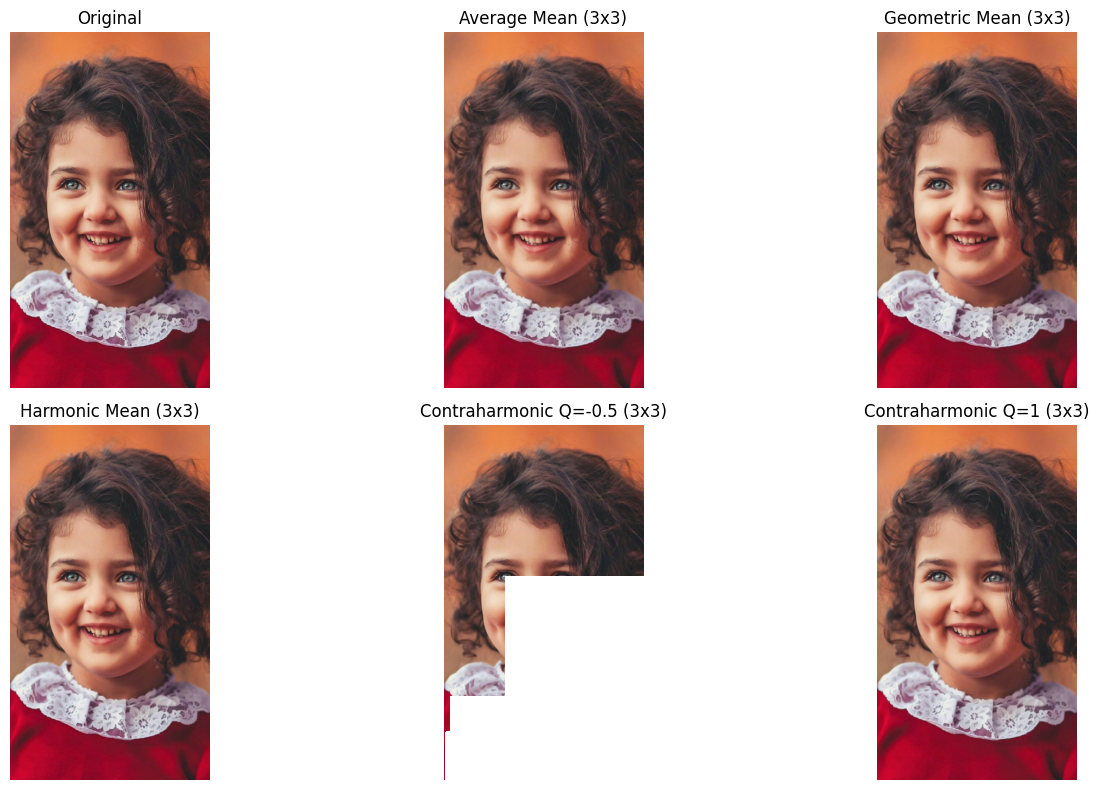

In [3]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# ---------------------------
# Parameters
# ---------------------------
img_path = "pk.jpg"  # change if needed
kr, kc = 3, 3        # kernel size
eps = 1e-8

# ---------------------------
# Helper filter functions (operate on 2D channel arrays)
# ---------------------------
def average_mean_filter(channel, kr, kc):
    # uniform_filter returns the local mean
    return uniform_filter(channel, size=(kr, kc), mode='nearest')

def geometric_mean_filter(channel, kr, kc):
    # geometric mean = exp( mean( log(x) ) )
    log_ch = np.log(channel + eps)
    mean_log = uniform_filter(log_ch, size=(kr, kc), mode='nearest')
    return np.exp(mean_log)

def harmonic_mean_filter(channel, kr, kc):
    # harmonic mean = 1 / mean(1/x)
    mean_inv = uniform_filter(1.0 / (channel + eps), size=(kr, kc), mode='nearest')
    return 1.0 / (mean_inv + eps)

def contraharmonic_mean_filter(channel, kr, kc, Q):
    # contraharmonic = sum(x^(Q+1)) / sum(x^Q)
    # uniform_filter returns mean; ratio of means == ratio of sums
    num = uniform_filter(channel ** (Q + 1), size=(kr, kc), mode='nearest')
    den = uniform_filter(channel ** Q, size=(kr, kc), mode='nearest')
    return num / (den + eps)

# ---------------------------
# Read image and prepare
# ---------------------------
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found at '{img_path}'")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0  # normalize to [0,1]
h, w, ch = img.shape

# Prepare result containers
avg_res = np.zeros_like(img)
geo_res = np.zeros_like(img)
harm_res = np.zeros_like(img)
contra_neg_res = np.zeros_like(img)
contra_pos_res = np.zeros_like(img)

# ---------------------------
# Apply filters channel-wise
# ---------------------------
for c in range(ch):
    channel = img[:, :, c]
    avg_res[:, :, c] = average_mean_filter(channel, kr, kc)
    geo_res[:, :, c] = geometric_mean_filter(channel, kr, kc)
    harm_res[:, :, c] = harmonic_mean_filter(channel, kr, kc)
    contra_neg_res[:, :, c] = contraharmonic_mean_filter(channel, kr, kc, Q=-0.5)
    contra_pos_res[:, :, c] = contraharmonic_mean_filter(channel, kr, kc, Q=1)

# Clip to [0,1] for display
images = [
    np.clip(img, 0, 1),
    np.clip(avg_res, 0, 1),
    np.clip(geo_res, 0, 1),
    np.clip(harm_res, 0, 1),
    np.clip(contra_neg_res, 0, 1),
    np.clip(contra_pos_res, 0, 1),
]
titles = [
    "Original",
    f"Average Mean ({kr}x{kc})",
    f"Geometric Mean ({kr}x{kc})",
    f"Harmonic Mean ({kr}x{kc})",
    f"Contraharmonic Q=-0.5 ({kr}x{kc})",
    f"Contraharmonic Q=1 ({kr}x{kc})",
]

# ---------------------------
# Display
# ---------------------------
plt.figure(figsize=(15, 8))
for i, (im, t) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(im)
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import cv2

original = cv2.imread('pk.jpg', cv2.IMREAD_UNCHANGED)
cv2.imshow('original', original)

#--------------------<Domain Filter>--------------------#
domainFilter = cv2.edgePreservingFilter(original, flags=1, sigma_s=60, sigma_r=0.6)
cv2.imshow('Domain Filter',domainFilter)

#--------------------<Gaussian Blur Method>--------------------#
gaussBlur = cv2.GaussianBlur(original,(5,5),cv2.BORDER_DEFAULT)
cv2.imshow("Gaussian Smoothing",gaussBlur)

#--------------------<Gaussian Blur Method>--------------------#
kernel = np.ones((10,10),np.float32)/25
meanFilter = cv2.filter2D(original, -1, kernel)
cv2.imshow("Mean Filtered Image", meanFilter)

#--------------------<Gaussian Blur Method>--------------------#
medianFilter = cv2.medianBlur(original,5)
cv2.imshow("Median Filter", medianFilter)

#--------------------<Bilateral Filtering Techniques>--------------------#
bilFil = cv2.bilateralFilter(original, 60, 60, 60)
cv2.imshow("Bilateral Filter", bilFil)

#--------------------<Frequency Band Filtering Techniques>--------------------#
## For High Band Pass Filter
highPass = original - gaussBlur

## For Low Band Pass Filter
lowPass = cv2.filter2D(original, -1, kernel)
lowPass = original - lowPass

cv2.imshow("High Pass\t\t\t\t     Low Pass", np.hstack((highPass, lowPass)))

cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
import numpy as np
import cv2

# Read image
original = cv2.imread('pk.jpg', cv2.IMREAD_COLOR)
if original is None:
    raise FileNotFoundError("Image 'pk.jpg' not found. Please check the file path.")

cv2.imshow('Original', original)

# --------------------<Domain Filter>-------------------- #
domainFilter = cv2.edgePreservingFilter(original, flags=1, sigma_s=60, sigma_r=0.6)
cv2.imshow('Domain Filter', domainFilter)

# --------------------<Gaussian Blur Method>-------------------- #
gaussBlur = cv2.GaussianBlur(original, (5, 5), 0)
cv2.imshow("Gaussian Smoothing", gaussBlur)

# --------------------<Mean Filter>-------------------- #
kernel = np.ones((10, 10), np.float32) / 100   # ✅ Fixed divisor to match kernel size
meanFilter = cv2.filter2D(original, -1, kernel)
cv2.imshow("Mean Filtered Image", meanFilter)

# --------------------<Median Filter>-------------------- #
medianFilter = cv2.medianBlur(original, 5)
cv2.imshow("Median Filter", medianFilter)

# --------------------<Bilateral Filtering Technique>-------------------- #
bilFil = cv2.bilateralFilter(original, 15, 75, 75)
cv2.imshow("Bilateral Filter", bilFil)

# --------------------<Frequency Band Filtering Techniques>-------------------- #
# High-pass emphasizes edges, Low-pass emphasizes smooth areas
highPass = cv2.subtract(original, gaussBlur)
lowPass = cv2.subtract(original, meanFilter)

# Stack images side by side for comparison
combined = np.hstack((highPass, lowPass))
cv2.imshow("High Pass (Left) vs Low Pass (Right)", combined)

cv2.waitKey(0)
cv2.destroyAllWindows()


FileNotFoundError: Image 'pk.jpg' not found. Please check the file path.